# 3D Porous Media — Two Spheres (LBM Simulation)
## JAX D3Q19 Lattice Boltzmann Method with Zou-He Boundary Conditions

This notebook runs a 3D Lattice Boltzmann simulation of flow through a porous medium
consisting of two spheres, using the D3Q19 lattice model implemented in JAX.

**Features:**
- D3Q19 lattice with BGK collision operator
- Zou-He pressure boundary conditions at inlet/outlet
- Bounce-back for solid nodes
- Convergence check based on mean velocity
- Permeability calculation and comparison with Palabos reference

## 1. Imports

In [1]:
import jax
# Enable float64 precision (Palabos uses typedef double T).
# Must be set BEFORE any JAX arrays are created.
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import jit
import numpy as np
import time

print(f"JAX devices: {jax.devices()}")
print(f"JAX x64 enabled: {jax.config.read('jax_enable_x64')}")


JAX devices: [cuda(id=0), cuda(id=1), cuda(id=2)]
JAX x64 enabled: True


## 2. Simulation Parameters

These parameters are set to match the Palabos reference case.

In [2]:
# Raw grid dimensions (before padding)
NX_RAW, NY_RAW, NZ_RAW = 48, 64, 64

# Relaxation parameters
OMEGA = 1.0
TAU = 1.0
NU = 1.0 / 6.0

# Pressure drop
DELTA_P = 0.00005
RHO_IN = 1.0
RHO_OUT = 1.0 - DELTA_P * 3.0

# Simulation control
MAX_STEPS = 300000
PRINT_EVERY = 500
CONV = 1e-4                 # Palabos util::ValueTracer epsilon

# Convergence window size in LBM steps.
# Palabos' ValueTracer default is 1000; we use the same.
# window_samples = CONV_WINDOW // PRINT_EVERY = 2 with the settings above.
CONV_WINDOW = 1000

# Palabos breaks on a single sub-threshold check once the window is full.
CONV_CONSEC = 3

# Lattice directions
Q = 19

print(f"Raw grid: {NX_RAW}x{NY_RAW}x{NZ_RAW}  omega={OMEGA}  nu={NU:.6f}  dP={DELTA_P}")


Raw grid: 48x64x64  omega=1.0  nu=0.166667  dP=5e-05


## 3. D3Q19 Lattice Definition

Define the lattice velocities, weights, and opposite directions for the D3Q19 model.

In [3]:
# D3Q19 lattice velocities
C = np.array([
    [0,0,0],                                          # rest
    [1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1],  # face neighbours
    [1,1,0],[-1,-1,0],[1,-1,0],[-1,1,0],              # edge neighbours (xy)
    [1,0,1],[-1,0,-1],[1,0,-1],[-1,0,1],              # edge neighbours (xz)
    [0,1,1],[0,-1,-1],[0,1,-1],[0,-1,1]               # edge neighbours (yz)
], dtype=np.int32)

# Weights
W = np.array([1./3.] + [1./18.]*6 + [1./36.]*12, dtype=np.float64)

# Opposite direction indices
OPP = np.array([0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15, 18, 17])

# Reshaped arrays for broadcasting (4D: Q x NX x NY x NZ)
cx4 = jnp.array(C[:,0], dtype=jnp.float64).reshape(Q,1,1,1)
cy4 = jnp.array(C[:,1], dtype=jnp.float64).reshape(Q,1,1,1)
cz4 = jnp.array(C[:,2], dtype=jnp.float64).reshape(Q,1,1,1)
w4  = jnp.array(W, dtype=jnp.float64).reshape(Q,1,1,1)

# Reshaped arrays for broadcasting (3D: Q x NY x NZ) — used in BC
cx2 = jnp.array(C[:,0], dtype=jnp.float64).reshape(Q,1,1)
cy2 = jnp.array(C[:,1], dtype=jnp.float64).reshape(Q,1,1)
cz2 = jnp.array(C[:,2], dtype=jnp.float64).reshape(Q,1,1)
w2  = jnp.array(W, dtype=jnp.float64).reshape(Q,1,1)
opp = jnp.array(OPP)

# Direction groups for Zou-He BC
POS_X  = jnp.array([1, 7, 9, 11, 13])   # positive x-velocity directions
NEG_X  = jnp.array([2, 8, 10, 12, 14])  # negative x-velocity directions
ZERO_X = jnp.array([0, 3, 4, 5, 6, 15, 16, 17, 18])  # zero x-velocity

print("D3Q19 lattice initialised.")

# Axial vs diagonal splits (used in proper Zou-He reconstruction)
POS_X_AXIAL    = jnp.array([1])              # +x face-normal
POS_X_DIAG     = jnp.array([7, 9, 11, 13])   # +x diagonals (unknowns at inlet)
NEG_X_AXIAL    = jnp.array([2])              # -x face-normal
NEG_X_DIAG     = jnp.array([8, 10, 12, 14])  # -x diagonals (unknowns at outlet)


D3Q19 lattice initialised.


## 4. Geometry Loading & Padding

Read the `twoSpheres.dat` geometry file. Node types:
- **0** = fluid
- **1** = bounce-back (solid)
- **2** = no-dynamics (exterior)

**Padding strategy (supervisor's approach for x-direction flow):**
1. **One layer of solid (BB=1)** on both sides of y and z (cross-flow walls).
2. **One layer of void/fluid (0)** at the outlet end of x (flow direction) for better convergence.

Padding is excluded when computing permeability and other physical quantities.

In [4]:
print("Reading geometry...")
geo_raw = np.loadtxt("twoSpheres.dat", dtype=int).reshape(NX_RAW, NY_RAW, NZ_RAW)
geo_raw[-1, :, :] = 0  # Palabos reads only nx-1 slices

print(f"  Raw shape: {geo_raw.shape}")
print(f"  Raw — Fluid={int(np.sum(geo_raw==0))}  BB={int(np.sum(geo_raw==1))}  ND={int(np.sum(geo_raw==2))}")

# ── Conditional y/z padding ────────────────────────────────────────
# Our stream() uses periodic jnp.roll. Palabos does non-periodic
# streaming, achieved in practice by having solid cells on the y/z
# outer faces. If any fluid touches the outer y/z faces, periodic
# streaming will non-physically couple opposite sides, so we pad
# those faces with a solid (bounce-back) layer. If the outer faces
# are already all solid, no padding is needed.

fluid_on_y0  = int(np.sum(geo_raw[:, 0,  :] == 0))
fluid_on_yN  = int(np.sum(geo_raw[:, -1, :] == 0))
fluid_on_z0  = int(np.sum(geo_raw[:, :, 0]  == 0))
fluid_on_zN  = int(np.sum(geo_raw[:, :, -1] == 0))
need_y_pad = (fluid_on_y0 + fluid_on_yN) > 0
need_z_pad = (fluid_on_z0 + fluid_on_zN) > 0
print(f"  Fluid on outer y-faces: y=0 has {fluid_on_y0}, y=NY-1 has {fluid_on_yN}")
print(f"  Fluid on outer z-faces: z=0 has {fluid_on_z0}, z=NZ-1 has {fluid_on_zN}")

pad_y = (1, 1) if need_y_pad else (0, 0)
pad_z = (1, 1) if need_z_pad else (0, 0)

if need_y_pad or need_z_pad:
    geo = np.pad(geo_raw,
                 pad_width=((0, 0), pad_y, pad_z),
                 mode="constant", constant_values=1)   # solid pad
    print(f"  Padding applied:  y={pad_y}  z={pad_z}  (solid layers)")
else:
    geo = geo_raw
    print("  No padding needed (outer y/z faces already solid).")

# Update grid dimensions after (possibly) padding
NX, NY, NZ = geo.shape
print(f"  Final grid: {NX} x {NY} x {NZ}")
print(f"  Final — Fluid={int(np.sum(geo==0))}  BB={int(np.sum(geo==1))}  ND={int(np.sum(geo==2))}")

# Boolean masks (with leading singleton dim for broadcasting with f)
is_fluid = jnp.array(geo == 0)[None]
is_bb    = jnp.array(geo == 1)[None]
is_nd    = jnp.array(geo == 2)[None]

# Inlet / outlet masks — interior fluid cells on x-faces
inm  = np.zeros((NY, NZ), bool)
outm = np.zeros((NY, NZ), bool)
inm[1:NY-1, 1:NZ-1]  = (geo[0,  1:NY-1, 1:NZ-1] == 0)
outm[1:NY-1, 1:NZ-1] = (geo[-1, 1:NY-1, 1:NZ-1] == 0)
inlet_mask  = jnp.array(inm)[None]
outlet_mask = jnp.array(outm)[None]

print(f"  Inlet fluid nodes  = {int(np.sum(inm))}")
print(f"  Outlet fluid nodes = {int(np.sum(outm))}")

# Record padding amounts for later use (e.g. permeability stripping)
PAD_Y = pad_y
PAD_Z = pad_z


Reading geometry...
  Raw shape: (48, 64, 64)
  Raw — Fluid=109835  BB=13632  ND=73141
  Fluid on outer y-faces: y=0 has 64, y=NY-1 has 64
  Fluid on outer z-faces: z=0 has 64, z=NZ-1 has 64
  Padding applied:  y=(1, 1)  z=(1, 1)  (solid layers)
  Final grid: 48 x 66 x 66
  Final — Fluid=109835  BB=26112  ND=73141
  Inlet fluid nodes  = 2821
  Outlet fluid nodes = 4096


### 4a. Before & After Padding

Side-by-side comparison of the geometry before and after padding.
- **White** = fluid (0), **Black** = bounce-back / solid (1), **Grey** = no-dynamics (2)
- Red dashed lines = y solid padding, green dashed lines = z solid padding, blue dashed line = x outlet void layer.

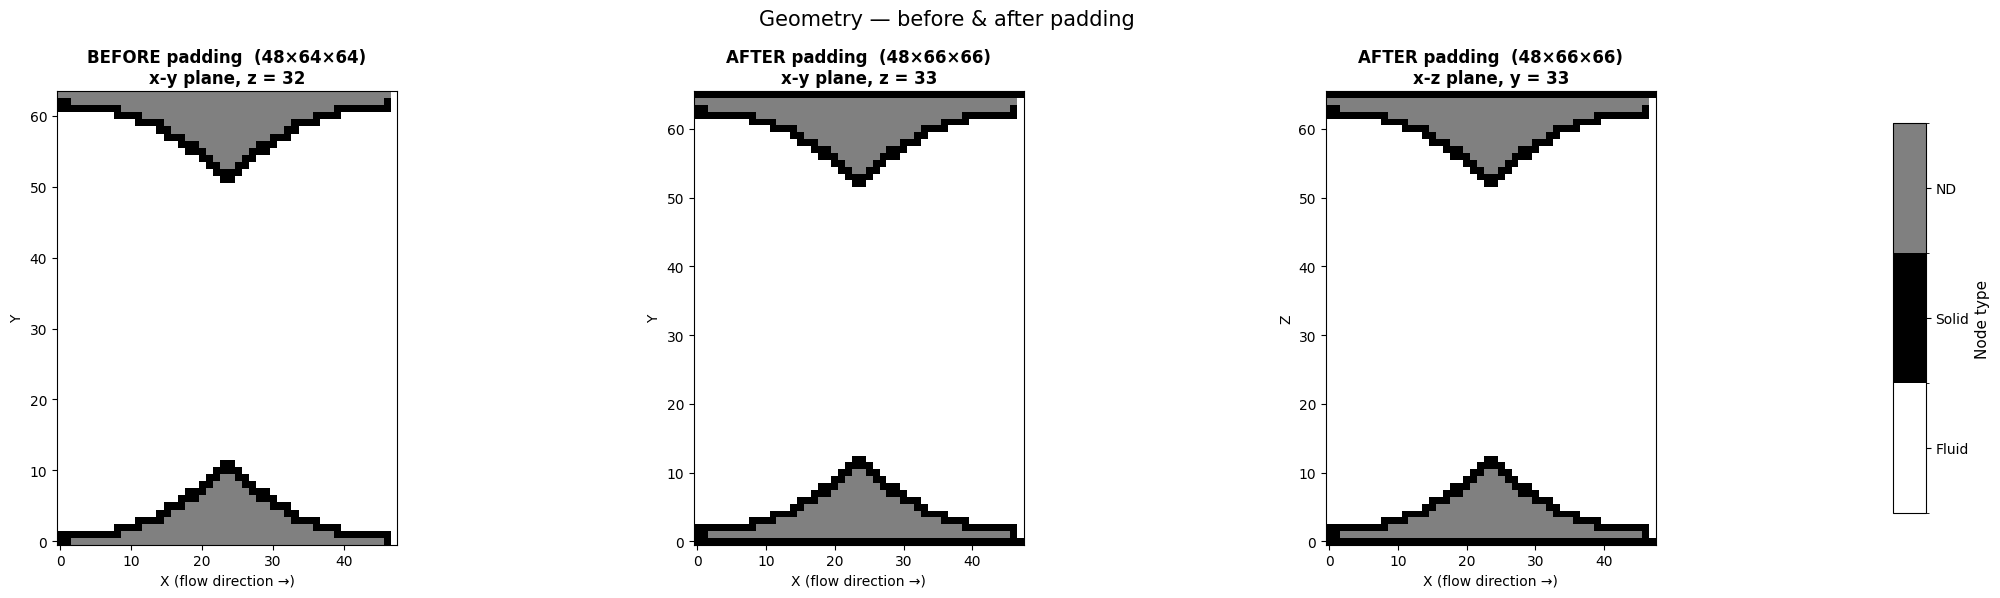

Original domain : 48 x 64 x 64
Padded domain   : 48 x 66 x 66
  y: +1 solid each side   (64 -> 66)
  z: +1 solid each side   (64 -> 66)
  x: +1 void at outlet    (48 -> 48)


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Custom colourmap: fluid=white, solid=black, ND=grey
cmap_geo = mcolors.ListedColormap(['white', 'black', 'grey'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm_geo = mcolors.BoundaryNorm(bounds, cmap_geo.N)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Left: BEFORE padding (raw geometry, x-y plane at mid-z) ──
zc_raw = NZ_RAW // 2
ax = axes[0]
im = ax.imshow(geo_raw[:, :, zc_raw].T, origin='lower',
               cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'BEFORE padding  ({NX_RAW}×{NY_RAW}×{NZ_RAW})\nx-y plane, z = {zc_raw}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Y')

# ── Centre: AFTER padding (x-y plane at mid-z — shows y padding + outlet void) ──
zc = NZ // 2
ax = axes[1]
ax.imshow(geo[:, :, zc].T, origin='lower',
          cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'AFTER padding  ({NX}×{NY}×{NZ})\nx-y plane, z = {zc}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Y')
# y-direction solid padding
# ax.axhline(0.5, color='red', ls='--', lw=1.5, label='y solid pad')
# ax.axhline(NY - 1.5, color='red', ls='--', lw=1.5)
# # x-direction outlet void layer
# ax.axvline(NX - 1.5, color='blue', ls='--', lw=1.5, label='x outlet void')
# ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# ── Right: AFTER padding (x-z plane at mid-y — shows z padding + outlet void) ──
yc = NY // 2
ax = axes[2]
ax.imshow(geo[:, yc, :].T, origin='lower',
          cmap=cmap_geo, norm=norm_geo, aspect='equal')
ax.set_title(f'AFTER padding  ({NX}×{NY}×{NZ})\nx-z plane, y = {yc}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X (flow direction →)'); ax.set_ylabel('Z')
# z-direction solid padding
# ax.axhline(0.5, color='green', ls='--', lw=1.5, label='z solid pad')
# ax.axhline(NZ - 1.5, color='green', ls='--', lw=1.5)
# # x-direction outlet void layer
# ax.axvline(NX - 1.5, color='blue', ls='--', lw=1.5, label='x outlet void')
# ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# Colorbar: manually placed far right
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.65])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0, 1, 2])
cbar.set_label('Node type', fontsize=11)
cbar.ax.set_yticklabels(['Fluid', 'Solid', 'ND'])

fig.suptitle('Geometry — before & after padding', fontsize=15, y=0.99)
plt.show()

print(f"Original domain : {NX_RAW} x {NY_RAW} x {NZ_RAW}")
print(f"Padded domain   : {NX} x {NY} x {NZ}")
print(f"  y: +1 solid each side   ({NY_RAW} -> {NY})")
print(f"  z: +1 solid each side   ({NZ_RAW} -> {NZ})")
print(f"  x: +1 void at outlet    ({NX_RAW} -> {NX})")

## 5. Core LBM Functions

Equilibrium distribution, macroscopic quantities, streaming, and boundary conditions.

In [6]:
def eq3d(rho, ux, uy, uz):
    """Equilibrium distribution (full 3D field)."""
    usq = ux*ux + uy*uy + uz*uz
    cu  = cx4*ux[None] + cy4*uy[None] + cz4*uz[None]
    return w4 * rho[None] * (1 + 3*cu + 4.5*cu*cu - 1.5*usq[None])

def eq2d(rho, ux, uy, uz):
    """Equilibrium distribution (2D slice, for BCs)."""
    usq = ux*ux + uy*uy + uz*uz
    cu  = cx2*ux[None] + cy2*uy[None] + cz2*uz[None]
    return w2 * rho[None] * (1 + 3*cu + 4.5*cu*cu - 1.5*usq[None])

def macro(f):
    """Compute macroscopic quantities from distribution."""
    rho = jnp.sum(f, 0)
    ux  = jnp.sum(f * cx4, 0) / rho
    uy  = jnp.sum(f * cy4, 0) / rho
    uz  = jnp.sum(f * cz4, 0) / rho
    return rho, ux, uy, uz

def stream(f):
    """Streaming step: shift each population along its lattice velocity."""
    out = jnp.zeros_like(f)
    for q in range(Q):
        s = jnp.roll(f[q], C[q,0], 0)
        s = jnp.roll(s,    C[q,1], 1)
        s = jnp.roll(s,    C[q,2], 2)
        out = out.at[q].set(s)
    return out

print("Core functions defined.")

Core functions defined.


## 6. Zou-He Pressure Boundary Conditions

Pressure-driven flow: set density (pressure) at inlet and outlet faces.

In [7]:
def zou_he_inlet(f):
    """Zou-He pressure BC at inlet (x = 0).

    Reconstructs only the UNKNOWN (inward-pointing) populations
    {1, 7, 9, 11, 13} using non-equilibrium bounce-back:
        f_i = f_opp(i) + f_i^eq - f_opp(i)^eq
    evaluated at (rho_in, ux_in, 0, 0). Knowns (ZERO_X, NEG_X) are
    left untouched. This matches Palabos' RegularizedBoundaryCondition
    for zero tangential velocity."""
    s = f[:, 0, :, :]                                   # (Q, NY, NZ)
    rho_in = RHO_IN * jnp.ones((NY, NZ))

    # Derive ux from known moments: rho = sum_zero + 2*sum_neg + rho*ux
    ux_in = 1.0 - (jnp.sum(s[ZERO_X], 0) + 2*jnp.sum(s[NEG_X], 0)) / rho_in

    # Equilibrium at imposed (rho_in, ux_in, 0, 0) for all 19 dirs on the face
    feq_face = eq2d(rho_in, ux_in,
                    jnp.zeros((NY, NZ)), jnp.zeros((NY, NZ)))  # (Q, NY, NZ)

    # Reconstruct unknowns: f_i = f_opp(i) + feq_i - feq_opp(i)
    s_new = s
    for i, j in [(1, 2), (7, 8), (9, 10), (11, 12), (13, 14)]:
        new_i = s[j] + feq_face[i] - feq_face[j]
        s_new = s_new.at[i].set(jnp.where(inlet_mask[0], new_i, s[i]))

    return f.at[:, 0, :, :].set(s_new)


def zou_he_outlet(f):
    """Zou-He pressure BC at outlet (x = NX-1).

    Unknowns here are the NEG_X populations {2, 8, 10, 12, 14} — the ones
    that would stream into the fluid from the +x side, which doesn't exist.
    Same reconstruction rule, with (rho_out, ux_out, 0, 0)."""
    s = f[:, -1, :, :]
    rho_out = RHO_OUT * jnp.ones((NY, NZ))

    # Derive ux from known moments on the outlet face
    ux_out = -1.0 + (jnp.sum(s[ZERO_X], 0) + 2*jnp.sum(s[POS_X], 0)) / rho_out

    feq_face = eq2d(rho_out, ux_out,
                    jnp.zeros((NY, NZ)), jnp.zeros((NY, NZ)))

    s_new = s
    for i, j in [(2, 1), (8, 7), (10, 9), (12, 11), (14, 13)]:
        new_i = s[j] + feq_face[i] - feq_face[j]
        s_new = s_new.at[i].set(jnp.where(outlet_mask[0], new_i, s[i]))

    return f.at[:, -1, :, :].set(s_new)


print("Boundary condition functions defined (proper Zou-He, unknowns-only).")


Boundary condition functions defined (proper Zou-He, unknowns-only).


## 7. LBM Time Step

One complete LBM step: collision → streaming → boundary conditions.

In [8]:
@jit
def one_step(f, is_fluid, is_bb, is_nd):
    """Single LBM time step."""
    # Collision: fluid → BGK, bounce-back → swap, no-dynamics → skip
    _, ux, uy, uz = macro(f)
    rho = jnp.sum(f, 0)
    feq = eq3d(rho, ux, uy, uz)
    f_coll = jnp.where(is_bb, f[opp],
             jnp.where(is_nd, f,
                        f - (f - feq) / TAU))
    # Streaming
    f_str = stream(f_coll)
    # Zou-He pressure BC
    f_str = zou_he_inlet(f_str)
    f_str = zou_he_outlet(f_str)
    return f_str

print("one_step function defined.")

one_step function defined.


## 8. Initialisation

Start with a linear pressure gradient from inlet to outlet.

In [9]:
print("Initialising distribution functions...")
x = np.arange(NX, dtype=np.float64)
rho0 = jnp.array(
    np.broadcast_to(
        (1.0 - DELTA_P * 3 / (NX-1) * x)[:, None, None],
        (NX, NY, NZ)
    ).copy()
)
z = jnp.zeros((NX, NY, NZ), dtype=jnp.float64)
f = eq3d(rho0, z, z, z)

# JIT warm-up
print("JIT compiling (first call)...")
t0 = time.time()
f = one_step(f, is_fluid, is_bb, is_nd)
f.block_until_ready()
print(f"JIT compilation took {time.time()-t0:.1f} s")

Initialising distribution functions...
JIT compiling (first call)...
JIT compilation took 0.6 s


## 9. Main Simulation Loop

**Convergence criterion (Palabos-style):**
Track the average kinetic energy ½ρ|u|² over the entire lattice.
A sliding window average (window = 1000 iterations) is compared every
500 steps; the simulation stops when the relative change drops below 1e-4.

This mirrors Palabos's `util::ValueTracer` with `getStoredAverageEnergy`.

In [10]:
def compute_avg_energy(f):
    """Average kinetic energy over FLUID nodes only.
    This matches Palabos getStoredAverageEnergy(), which is an average
    over the BulkDynamics (fluid) cells — solid bounce-back cells and
    no-dynamics cells are excluded."""
    rho = jnp.sum(f, 0)
    ux  = jnp.sum(f * cx4, 0) / rho
    uy  = jnp.sum(f * cy4, 0) / rho
    uz  = jnp.sum(f * cz4, 0) / rho
    energy = 0.5 * rho * (ux**2 + uy**2 + uz**2)
    # is_fluid has shape (1, NX, NY, NZ); squeeze the leading dim to match
    fluid3d = is_fluid[0]
    numerator   = jnp.sum(jnp.where(fluid3d, energy, 0.0))
    denominator = jnp.sum(fluid3d)
    return float(numerator / denominator)

# Derived: how many sampled points make up one convergence window.
window_samples = max(2, CONV_WINDOW // PRINT_EVERY)

print(f"Running simulation (max {MAX_STEPS} steps)...")
print(f"Convergence: window={CONV_WINDOW} steps ({window_samples} samples), "
      f"threshold={CONV}, require {CONV_CONSEC} consecutive passes")
t0 = time.time()

# Sliding window for energy values (sampled every PRINT_EVERY steps)
energy_history = []
prev_window_avg = None
consec_below = 0

for step in range(1, MAX_STEPS + 1):
    f = one_step(f, is_fluid, is_bb, is_nd)

    if step % PRINT_EVERY == 0:
        f.block_until_ready()
        avg_E = compute_avg_energy(f)
        energy_history.append(avg_E)

        # Window-averaged energy over the last `window_samples` samples.
        if len(energy_history) >= window_samples:
            window_avg = float(np.mean(energy_history[-window_samples:]))
        else:
            window_avg = float(np.mean(energy_history))

        # Relative change between successive window averages.
        if prev_window_avg is not None and window_avg != 0:
            rel = abs(window_avg - prev_window_avg) / abs(window_avg)
        else:
            rel = 1.0

        # Only start checking once the window is actually full — otherwise the
        # "window" averages early-transient values and `rel` is meaningless.
        window_full = len(energy_history) >= window_samples
        if window_full and rel < CONV:
            consec_below += 1
        else:
            consec_below = 0

        print(f"  step {step:6d}  <E> = {avg_E:.6e}  "
              f"window_avg = {window_avg:.6e}  rel = {rel:.2e}  "
              f"consec = {consec_below}/{CONV_CONSEC}")

        if consec_below >= CONV_CONSEC and step > CONV_WINDOW:
            print("  >>> CONVERGED (Palabos-style energy criterion)")
            break

        prev_window_avg = window_avg

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f} s  ({NX*NY*NZ*step/elapsed/1e6:.0f} MLUPS)")


Running simulation (max 300000 steps)...
Convergence: window=1000 steps (2 samples), threshold=0.0001, require 3 consecutive passes
  step    500  <E> = 3.225014e-08  window_avg = 3.225014e-08  rel = 1.00e+00  consec = 0/3
  step   1000  <E> = 6.108240e-08  window_avg = 4.666627e-08  rel = 3.09e-01  consec = 0/3
  step   1500  <E> = 7.480310e-08  window_avg = 6.794275e-08  rel = 3.13e-01  consec = 0/3
  step   2000  <E> = 8.052114e-08  window_avg = 7.766212e-08  rel = 1.25e-01  consec = 0/3
  step   2500  <E> = 8.280288e-08  window_avg = 8.166201e-08  rel = 4.90e-02  consec = 0/3
  step   3000  <E> = 8.369908e-08  window_avg = 8.325098e-08  rel = 1.91e-02  consec = 0/3
  step   3500  <E> = 8.404896e-08  window_avg = 8.387402e-08  rel = 7.43e-03  consec = 0/3
  step   4000  <E> = 8.418524e-08  window_avg = 8.411710e-08  rel = 2.89e-03  consec = 0/3
  step   4500  <E> = 8.423828e-08  window_avg = 8.421176e-08  rel = 1.12e-03  consec = 0/3
  step   5000  <E> = 8.425891e-08  window_avg = 8

## 10. Results & Permeability

Compute macroscopic fields, derive permeability via Darcy's law, and visualise the full flow field.

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# ── Macroscopic fields (full simulated domain) ──
rho, ux, uy, uz = macro(f)
ux_np  = np.array(ux)
uy_np  = np.array(uy)
uz_np  = np.array(uz)
rho_np = np.array(rho)
umag   = np.sqrt(ux_np**2 + uy_np**2 + uz_np**2)

solid       = (geo != 0)
fluid_mask  = (geo == 0)
umag_masked = np.where(solid, np.nan, umag)
rho_masked  = np.where(solid, np.nan, rho_np)

# ── Permeability: Darcy (superficial) velocity ──
# Strip any y/z solid padding added in cell 8, then average ux on the
# ORIGINAL interior using `slab.size` as the denominator (consistent
# numerator-denominator slab).

ys = slice(PAD_Y[0], NY - PAD_Y[1] if PAD_Y[1] else None)
zs = slice(PAD_Z[0], NZ - PAD_Z[1] if PAD_Z[1] else None)

ux_slab  = ux_np[:, ys, zs]
geo_slab = geo  [:, ys, zs]
slab_vol = ux_slab.size

ux_zeroed    = np.where(geo_slab == 0, ux_slab, 0.0)
avg_velocity = float(np.sum(ux_zeroed) / slab_vol)

# Pressure gradient is set across the simulated x-extent (padding only in y,z)
NX_sim = ux_slab.shape[0]
grad_P = DELTA_P / (NX_sim - 1)
K      = NU * avg_velocity / grad_P

# Mass-conservation sanity check: per-slice mean ux should be nearly constant
ux_slice_means = ux_zeroed.sum(axis=(1, 2)) / (ux_slab.shape[1] * ux_slab.shape[2])
slice_std_rel  = float(np.std(ux_slice_means) / (abs(np.mean(ux_slice_means)) + 1e-30))

palabos_ref = 27.7554
rel_err     = abs(K - palabos_ref) / palabos_ref * 100

print("=" * 62)
print(f"  Darcy permeability on unpadded slab ({NX_sim}x{ux_slab.shape[1]}x{ux_slab.shape[2]})")
print(f"  (stripped padding: y={PAD_Y}, z={PAD_Z})")
print("=" * 62)
print(f"  Average (Darcy) velocity = {avg_velocity:.6e}")
print(f"  Lattice viscosity nu     = {NU:g}")
print(f"  Grad P                   = {grad_P:.6e}")
print(f"  Permeability K           = {K:.6g}")
print(f"  Palabos ref              = {palabos_ref}")
print(f"  Relative error           = {rel_err:.2f}%")
print("-" * 62)
print(f"  Cross-section u_x variability (std/mean) = {slice_std_rel:.2%}")
print(f"    (<1% indicates mass conservation / steady state)")
print("=" * 62)
print(f"  |u| range in fluid       : [{np.nanmin(umag_masked):.2e}, "
      f"{np.nanmax(umag_masked):.2e}]")
print(f"  rho range in fluid       : [{np.nanmin(rho_masked):.6f}, "
      f"{np.nanmax(rho_masked):.6f}]")


  Darcy permeability on unpadded slab (48x64x64)
  (stripped padding: y=(1, 1), z=(1, 1))
  Average (Darcy) velocity = 1.771800e-04
  Lattice viscosity nu     = 0.166667
  Grad P                   = 1.063830e-06
  Permeability K           = 27.7582
  Palabos ref              = 27.7554
  Relative error           = 0.01%
--------------------------------------------------------------
  Cross-section u_x variability (std/mean) = 0.01%
    (<1% indicates mass conservation / steady state)
  |u| range in fluid       : [3.38e-14, 9.84e-04]
  rho range in fluid       : [0.999825, 1.000024]


### 10a. Summary Dashboard

### 10b. Velocity Magnitude — Mid-plane Slices

Three orthogonal cuts through the domain centre. Solid regions appear as NaN (dark).

/tmp/ipykernel_1545355/1085356826.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


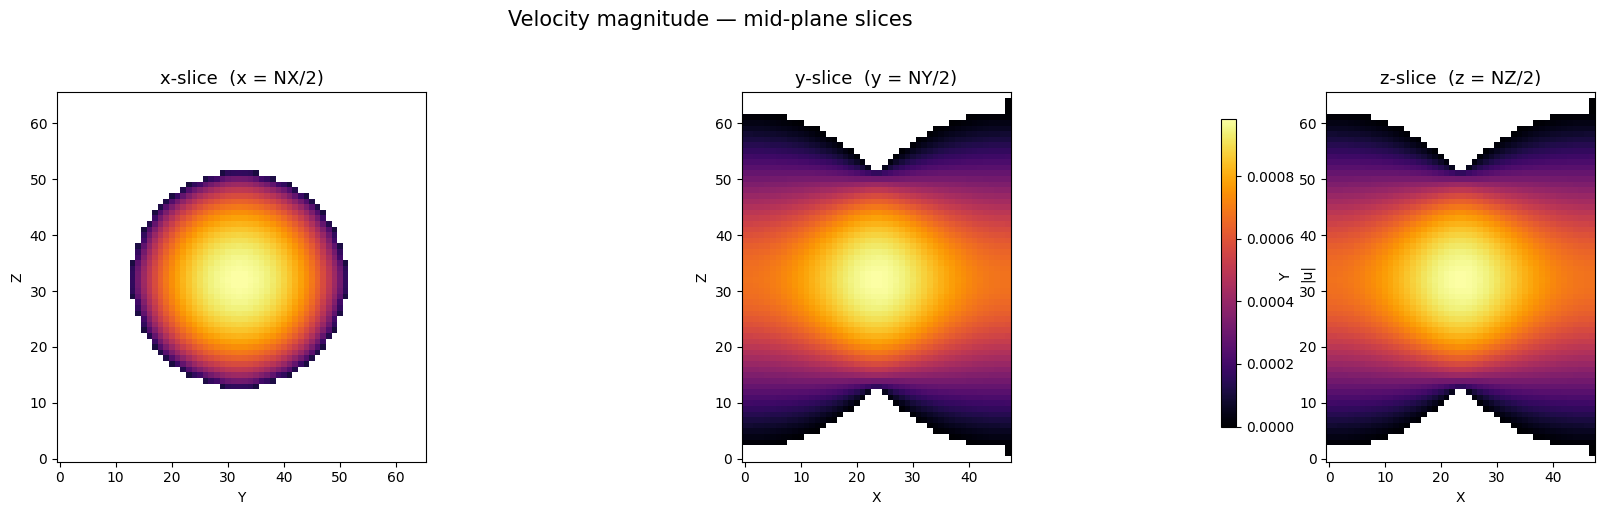

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

slices = [
    ("x-slice  (x = NX/2)",  umag_masked[NX//2, :, :],  "Y", "Z"),
    ("y-slice  (y = NY/2)",  umag_masked[:, NY//2, :],   "X", "Z"),
    ("z-slice  (z = NZ/2)",  umag_masked[:, :, NZ//2],   "X", "Y"),
]

vmax = np.nanmax(umag_masked)
for ax, (title, data, xl, yl) in zip(axes, slices):
    im = ax.imshow(data.T, origin='lower', cmap='inferno',
                   vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xl); ax.set_ylabel(yl)

fig.colorbar(im, ax=axes, label='|u|', shrink=0.8)
fig.suptitle('Velocity magnitude — mid-plane slices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 10c. Velocity Vectors — Mid-z Plane

Quiver plot of the in-plane velocity (u_x, u_y) coloured by speed,
with solid regions filled.

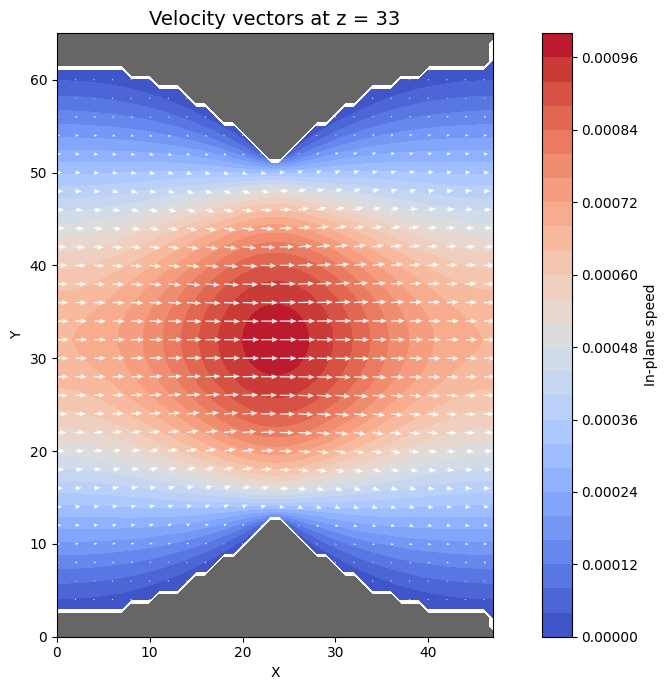

In [13]:
zc = NZ // 2
skip = 2  # subsample for clarity

yy, xx = np.meshgrid(np.arange(NY), np.arange(NX))

ux_sl = np.where(solid[:, :, zc], np.nan, ux_np[:, :, zc])
uy_sl = np.where(solid[:, :, zc], np.nan, uy_np[:, :, zc])
sp_sl = np.sqrt(ux_sl**2 + uy_sl**2)

fig, ax = plt.subplots(figsize=(10, 7))

cf = ax.contourf(xx, yy, sp_sl, levels=30, cmap='coolwarm')
plt.colorbar(cf, ax=ax, label='In-plane speed')

ax.contourf(xx, yy, solid[:, :, zc].astype(float),
            levels=[0.5, 1.5], colors='0.25', alpha=0.8)

ax.quiver(xx[::skip, ::skip], yy[::skip, ::skip],
          ux_sl[::skip, ::skip], uy_sl[::skip, ::skip],
          color='white', scale=None, width=0.003, headwidth=4, alpha=0.9)

ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Velocity vectors at z = {zc}', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 10d. Streamwise Velocity Profile

Cross-section-averaged u_x along the flow direction, showing acceleration
through the pore constriction.

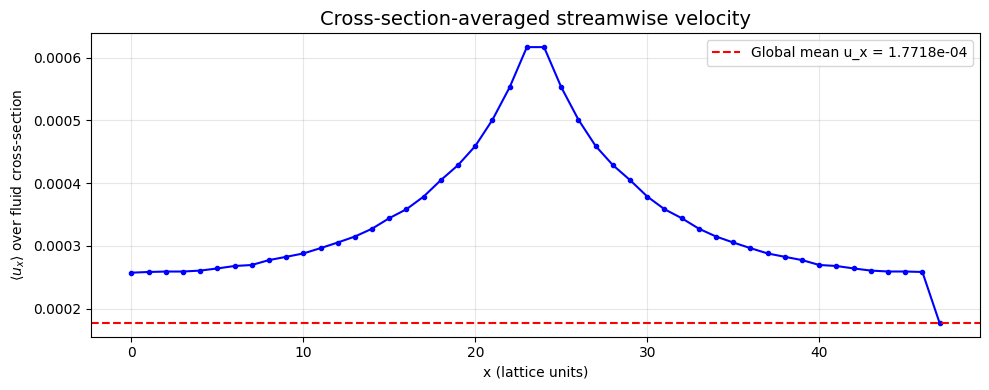

In [14]:
ux_profile = np.array([
    ux_np[i, fluid_mask[i]].mean() if fluid_mask[i].any() else 0.0
    for i in range(NX)
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(NX), ux_profile, 'b-o', markersize=3, linewidth=1.5)
ax.axhline(avg_velocity, color='r', ls='--',
           label=f'Global mean u_x = {avg_velocity:.4e}')
ax.set_xlabel('x (lattice units)')
ax.set_ylabel(r'$\langle u_x \rangle$ over fluid cross-section')
ax.set_title('Cross-section-averaged streamwise velocity', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10e. Pressure (Density) Field — Mid-z Plane

Density ρ is proportional to pressure (p = ρ c_s²). White contours mark the solid boundaries.

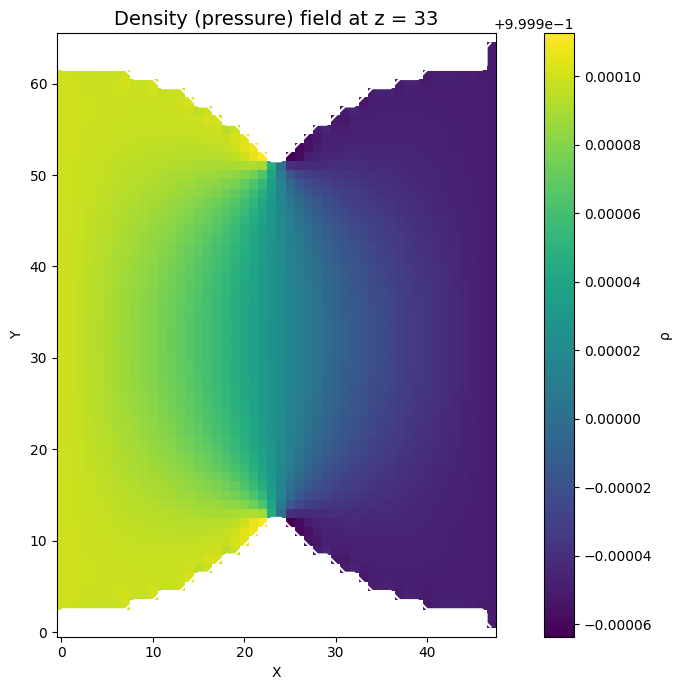

In [15]:
zc = NZ // 2

fig, ax = plt.subplots(figsize=(10, 7))
rho_sl = np.where(solid[:, :, zc], np.nan, rho_np[:, :, zc])

im = ax.imshow(rho_sl.T, origin='lower', cmap='viridis', aspect='equal')
ax.contour(solid[:, :, zc].T.astype(float), levels=[0.5],
           colors='white', linewidths=1.5)
plt.colorbar(im, ax=ax, label='ρ')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Density (pressure) field at z = {zc}', fontsize=14)
plt.tight_layout()
plt.show()

### 10f. 3D Geometry Visualisation

Solid voxels (bounce-back nodes) rendered in 3D, coloured by distance
from the domain centre to highlight the two spheres.

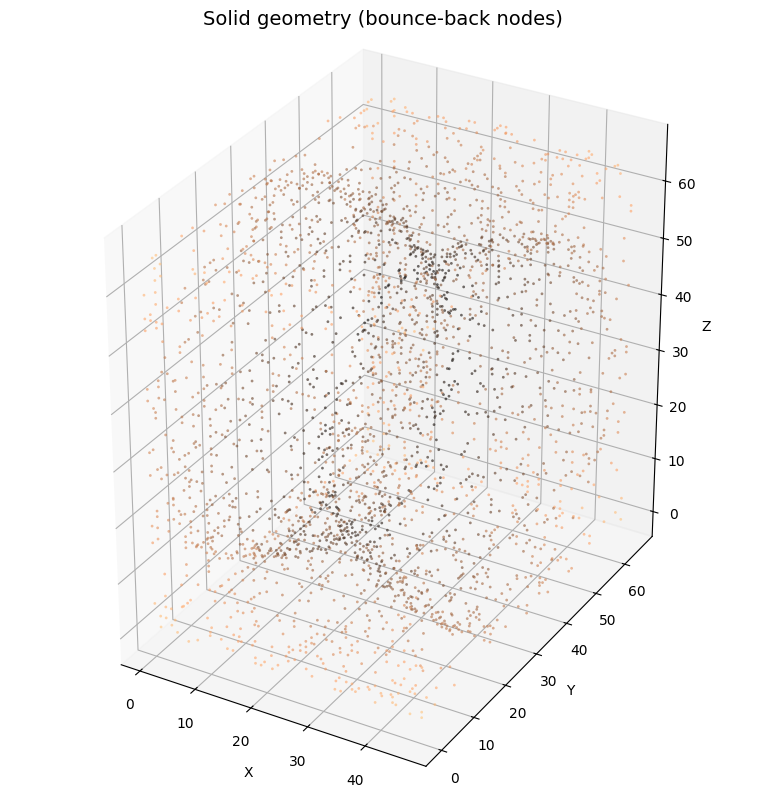

In [16]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

bb = (geo == 1)
xs, ys, zs = np.where(bb)

if len(xs) > 3000:
    idx = np.random.choice(len(xs), 3000, replace=False)
    xs, ys, zs = xs[idx], ys[idx], zs[idx]

cx_c, cy_c, cz_c = NX/2, NY/2, NZ/2
dist = np.sqrt((xs - cx_c)**2 + (ys - cy_c)**2 + (zs - cz_c)**2)
dist_norm = (dist - dist.min()) / (dist.max() - dist.min() + 1e-10)

ax.scatter(xs, ys, zs, c=dist_norm, cmap='copper', s=4, alpha=0.6, edgecolors='none')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Solid geometry (bounce-back nodes)', fontsize=14)
ax.set_box_aspect([NX, NY, NZ])
plt.tight_layout()
plt.show()

### 10g. Streamlines + Velocity Magnitude

In-plane streamlines overlaid on velocity magnitude at the mid-z plane,
with solid boundaries outlined in white.

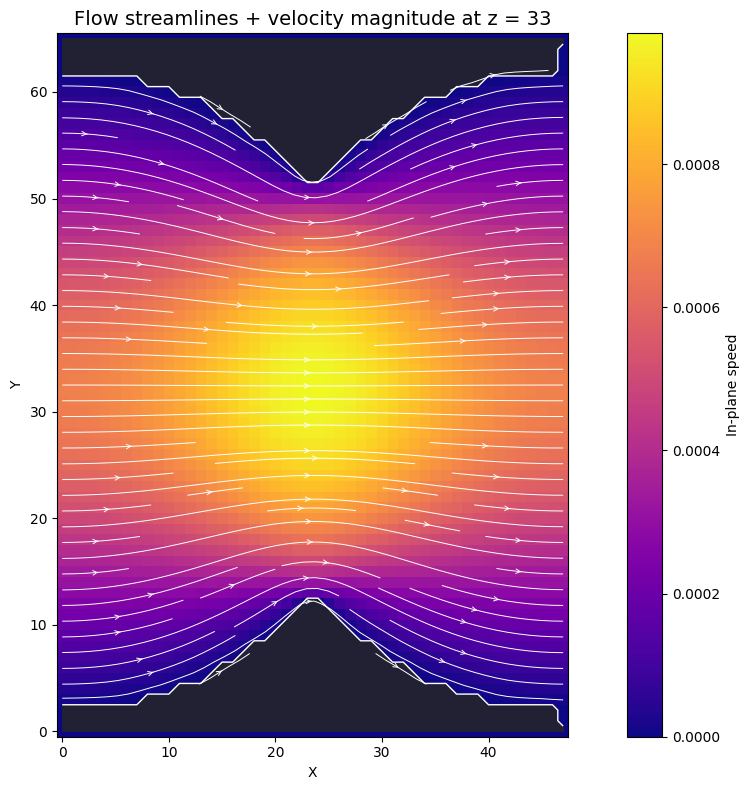

In [17]:
zc = NZ // 2

fig, ax = plt.subplots(figsize=(12, 8))

sp   = np.sqrt(ux_np[:, :, zc]**2 + uy_np[:, :, zc]**2)
sp_m = np.where(solid[:, :, zc], 0, sp)

im = ax.imshow(sp_m.T, origin='lower', cmap='plasma', aspect='equal')
plt.colorbar(im, ax=ax, label='In-plane speed')

ax.contourf(np.arange(NX), np.arange(NY), solid[:, :, zc].T.astype(float),
            levels=[0.5, 1.5], colors='0.15', alpha=0.85)
ax.contour(np.arange(NX), np.arange(NY), solid[:, :, zc].T.astype(float),
           levels=[0.5], colors='white', linewidths=1)

ux_stream = np.where(solid[:, :, zc], 0, ux_np[:, :, zc])
uy_stream = np.where(solid[:, :, zc], 0, uy_np[:, :, zc])

try:
    ax.streamplot(np.arange(NX), np.arange(NY),
                  ux_stream.T, uy_stream.T,
                  color='white', linewidth=0.7, density=1.5,
                  arrowsize=0.8, arrowstyle='->')
except:
    pass  # streamplot can fail for very small velocities

ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Flow streamlines + velocity magnitude at z = {zc}', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Save Results

In [18]:
np.savez("lbm_twospheres_results.npz",
    geometry=geo,
    ux=ux_np, uy=uy_np, uz=uz_np, rho=rho_np,
    permeability=K, mean_ux=avg_velocity,
    NX=NX, NY=NY, NZ=NZ, nu=NU, deltaP=DELTA_P
)
print("Saved → lbm_twospheres_results.npz")
print("\nAll results and visualisations complete.")

Saved → lbm_twospheres_results.npz

All results and visualisations complete.
